# Optimización de Rutas Logísticas: Implementación de Arbol-KD
**Cristian Álvarez Cuartas**
**Estructuras de Datos**

##1. **Introducción**
Este proyecto implementa un Quadtree, una estructura de datos de partición espacial que organiza puntos en un espacio. Para el caso, dichos puntos se mapean en un espacio de unicamente dos dimensiones. Este Quadtree de dos dimensiones permite entonces:
1. **Búsqueda por Radio:** Encontrar todos los puntos dentro de una distancia $r$.
2. **Vecino más Cercano (NN):** Localizar el punto más próximo a una coordenada dada.

## **Conceptualización inicial**

Un **Quadtree** es una estructura de datos de partición espacial que organiza los puntos dividiendo recursivamente el espacio en cuatro cuadrantes de igual área. Su funcionamiento se describe de la siguiente manera:

**1. División por cuadrícula simétrica**: El Quadtree, a diferencia del arbol KD, se basa en el **centro geométrico** del espacio. Dado un nodo que cubre una región delimitada por $[x_{min}, x_{max}]$ y $[y_{min}, y_{max}]$, se calcula el punto de división mediante:

$$\text{centro}_x = \frac{x_{min} + x_{max}}{2}, \quad \text{centro}_y = \frac{y_{min} + y_{max}}{2}$$



Este centro define los límites de los cuatro hijos del nodo, o en otras palabras, define las subregiones:
- Izquierda y arriba
-Izquierda y abajo
- Derecha y arriba
- Derecha y abajo

**2. Recursión:** El proceso se repite de forma recursiva. Si una región contiene más de un punto, se subdivide; si contiene un solo punto, se convierte en un **Nodo Hoja**, y si no contiene nigun punto, no se crea la subregion o el hijo.

Esta estructura permite optimizar las búsquedas espaciales mediante la **poda**: definimos un tipo de circulo de busqueda alrededor del punto objetivo, y un tipo de cuadrado con los puntos que definen la subregion (xmin,xmax,ymin,ymax). Si ese círculo se traslapa o toca con el rectángulo, entonces existe la posibilidad de que haya un punto dentro de dicha subregión que pueda ser vecino del punto objetivo:

$$\text{distancia}(\text{objetivo}, \text{rectángulo}) \leq r$$

Si no se cumple dicha condición, dentro de esa región no es posible que haya algún punto vecino al objetivo.

A través de esta poda, o de este filtro, podemos descartar regiones espaciales completas, de manera que no sea necesario recorrer y comparar el arbol completo, y que la eficiencia del árbol sea protagonista.

---


#PROBLEMA
Eres parte de un equipo que desarrolla un sistema de logistica de entregas en una ciudad.
Tienes coordenadas (x,y) de 10.000 puntos de entrega (estos datos los puedes tomar de datos reales
o generarlos, para este ejercicio los datos son estaticos, es decir, no cambian).

Necesitas implementar un sistema que responda eficientemente preguntas como:
* ¿que puntos de entrega estan a un radio de 500 metros de un punto dado? (tener en cuenta unidades)
* ¿cual es el puntos de entrega mas cercano a una ubicacion dada?

El objetivo del laboratorio es analizar cómo es el rendimiento de búsqueda para una distancia espacial en estructuras normales o de "Fuerza bruta" como en listas simples o arrays, comparado con la búsqueda dentro de un Quadtree.

---

## 2. Implementación del Algoritmo Quadtree  
El sistema se compone de la siguiente estructura de clases de python:

**Clase Nodo**: Representa una región del espacio. Almacena el centro de la subdivisión y referencias a sus cuatro hijos: izquierda-abajo, izquierda-arriba, derecha-abajo y derecha-arriba. En el caso de ser hoja, contiene un único punto.

**Clase Quadtree**: Contiene la lógica de construcción del árbol, junto con los algoritmos de búsqueda asociados (vecinos por radio y punto más cercano).

### Funciones Principales:

* `construir()`: Método recursivo que divide el espacio en cuatro cuadrantes a partir de los puntos medios:

$$
centroX = \frac{x_{min} + x_{max}}{2}, \quad centroY = \frac{y_{min} + y_{max}}{2}
$$

Los puntos se distribuyen en cada subregión correspondiente. El proceso continúa hasta que cada región contiene un único punto (nodo hoja).

---

* `buscarPorRadio()`: Se recorren las regiones desde la raíz, evaluando si el rectángulo de cada nodo intersecta con el círculo definido por el objetivo y el radio.  

Para esto se utiliza la distancia mínima entre el punto objetivo y el rectángulo:

$$
\text{distancia} = d(\text{objetivo}, \text{punto más cercano del rectángulo})
$$

Si esta distancia es menor o igual al radio, existe la posibilidad de encontrar puntos dentro de esa región, por lo que se continúa la búsqueda. En caso contrario, se descarta completamente esa subregión (poda).

Cuando se llega a una hoja, se calcula la distancia euclidiana al punto y se decide si se incluye dentro de los vecinos.

---

* `buscarMasCercano()`: Se recorre el árbol buscando el punto más cercano al objetivo. Se mantiene un candidato con la mejor distancia encontrada hasta el momento.

Para decidir si explorar una región, se evalúa si el rectángulo de esa región intersecta con el círculo definido por el objetivo y la distancia candidata actual:

$$
\text{distancia} \leq \text{mejor distancia encontrada}
$$

Si no hay intersección, se descarta la región (poda). En caso contrario, se continúa la búsqueda recursiva. Este proceso permite evitar explorar regiones que no pueden contener un punto más cercano.

---

Con esto el algoritmo realiza búsquedas eficientes aprovechando la partición espacial del Quadtree y reduciendo significativamente el número de comparaciones respecto a una búsqueda por fuerza bruta.

#**IMPLEMENTACIÓN PYTHON**
- **Consideraciones:** La implementación es únicamente útil para puntos en dos dimensiones. Además, las generaciones de gráficas fueron generadas totalmente por inteligencia artifical (en este caso, chatGPT y Gemini).

In [ ]:

"""FUNCION calcularDistancia(): recibe como parametros los puntos entre los que se quiere hallar la distancia.
Simplemente calcula la distancia euclidiana para cualquier dimension, restando entre componentes, elevando al cuadrado dicha resta, sumando el resultado anterior, y sacando la raiz cuadrada del resultado.
El retorno es la distancia calculada.

"""
def calcularDistancia(punto1, punto2):


    if not(len(punto1)==len(punto2)):
        print("Puntos en diferente dimension. No operable (si es operable pero no lo considero para el caso)") #Si bien podriamos mapear aquellos que sean de una dimension menos, en el origen de la dimension que les falta, para el caso no los consideramos.
        return
    resta = [] #Guardamos la resta por componentes
    for i in range (0, len(punto1)):
        resta.append(punto1[i]-punto2[i]) #Se agrega en la lista la resta de cada componente (xi-yi)
    distancia = 0 #Acumulador de la resta de las distancias al cuadrado
    for i in resta:
        distancia += i**2 # (xi - yi)**2
    distancia = distancia**0.5 #Raiz cuadrada del acumulador anterior.
    return distancia

"""FUNCION intersecta_rectangulo(): La idea es evaluar si, estableciendo un circulo con un centro centroCirculo, y estableciendo un rectangulo a partir del
rectangulo formado con los parametros xmin,xmax,ymin,ymax, evaluar si vale la pena entrar dentro de un nodo a buscar puntos cercanos (si el rectangulo y circulo se tocan),
o si ninguno de los puntos de la region cubierta por el nodo toca el circulo formado por centroCirculo y radio (no se tocan). Sirve para hacer poda."""

def intersecta_rectangulo(centroCirculo, radio, xmin, xmax, ymin,ymax):
    cerca_x = max(xmin, min(centroCirculo[0], xmax)) #encontramos en que parte esta el circulo en el eje x, si esta a la izquierda del rectangulo, "dentro" del rectangulo, o a la derecha del rectangulo.
    cerca_y = max(ymin, min(centroCirculo[1], ymax)) #encontramos si el circulo esta arriba del rectangulo, "dentro" del rectangulo o debajo del rectangulo (eje y).
    distancia = calcularDistancia(centroCirculo, (cerca_x, cerca_y)) #Creamos un punto con las dos coordenadas encontradas anteriormente, y calculamos si dicho punto esta o no esta dentro del radio del circulo.

    return distancia <= radio #Retornamos dicha distancia, para saber si puede haber un punto dentro del radio, o si no se tocan el circulo y rectangulo y por tanto
                                #es imposible que haya algun punto que buscar (poda).

class Nodo:
    def __init__(self, centro): #centro es simplemente la ubicacion coordenada que esta sirviendo como centro de referencia en cada rama del subarbol o en cada nodo
        self.centro = centro
        self.punto = None #Cuando se llegue a una hoja, guardamos el dato dentro de este atributo del nodo.
        self.izquierdaAbajo = None #Conexion con el nodo que guarda los puntos que estan a la izquierda del punto de referencia, y debajo del punto de referencia.
        self.izquierdaArriba = None #Conexion con el nodo que guarda los puntos que estan a la izquierda del punto de referencia, y arriba del punto de referencia.
        self.derechaArriba = None #Conexion con el nodo que guarda los puntos que estan a la derecha del punto de referencia, y arriba del punto de referencia.
        self.derechaAbajo = None #Conexion con el nodo que guarda los puntos que estan a la derecha del punto de referencia, y debajo del punto de referencia.

class Quadtree:
    def __init__(self, puntos, xmin, xmax, ymin, ymax): #Utilizamos la lista de puntos globales, y los limites de las coordenadas de los puntos globales. Esto, para la division por regiones "simetricas".
        self.limites= [xmin,xmax,ymin,ymax]
        self.raiz = self.construir(puntos, xmin,xmax,ymin,ymax)

    """METODO CONSTRUIR(): Recibe como parametro los puntos a mapear, y los puntos de referencia de la region (para la construccion del rectangulo).
    Vamos creando regiones simetricas con base a esos delimitadores enviados como parametros, hasta que las regiones encierren un unico dato."""

    def construir(self, puntos, xmin, xmax, ymin, ymax):
        if not puntos:
            return None

        if len(puntos) == 1: #
            hoja = Nodo(puntos[0])
            hoja.punto = puntos[0]
            return hoja  #Devolvemos el nodo una vez encierre un solo dato.

        centroX, centroY = (xmin + xmax) / 2, (ymin + ymax) / 2 #Hallamos los medios para realizar las divisiones.

        #Arreglos para guardar los puntos que entren dentro de cada region correspondiente
        izquierdaAbajo = []
        izquierdaArriba = []
        derechaArriba = []
        derechaAbajo = []

        for p in puntos:
            if p[0] < centroX:  #si esta a la izquierda sin pararse ninguna de las dos coordenadas sobre los ejes de division, se agrega al lado izquierdo
                if p[1] < centroY:
                    izquierdaAbajo.append(p)
                else:
                    # Si justo esta sobre la linea horizontal que divide a los de arriba y los de abajo, o si esta por encima de esa linea, se incluye en izquierdaArriba
                    izquierdaArriba.append(p)

            if p[0] >= centroX: #Si justo sobre vertical que divide a los de la derecha y los de la izquierda, o esta a la derecha de esa vertical:
                if p[1] < centroY: #Si ademas esta debajo de la horizontal que divide a los de arriba y a los de abajo, lo metemos en derechaAbajo.
                    derechaAbajo.append(p)
                else: #Si justo esta sobre la horizontal que divide a arriba y abajo, o esta encima de esta vertical, lo incluimos en derechaArriba.
                    derechaArriba.append(p)

        nodo_raiz = Nodo((centroX, centroY)) #creamos el "nodo raiz"  de cada subarbol y los vamos conectando.

        #Realizamos la ejecucion recursiva, de las subdivisiones y ubicacion de los puntos dentro de cada region, hasta que cada region encierre unicamente un punto.
        #Si uno de los hijos no tiene puntos o ya llegamos a una hoja, entonces el arreglo de puntos usado en el metodo recursivo queda vacio, de manera que no se crean mas hijos en este caso especifico por el caso base de la recursion (se corta esa rama)
        nodo_raiz.izquierdaAbajo = self.construir(izquierdaAbajo, xmin, centroX, ymin, centroY)
        nodo_raiz.izquierdaArriba = self.construir(izquierdaArriba, xmin, centroX, centroY, ymax)
        nodo_raiz.derechaAbajo = self.construir(derechaAbajo, centroX, xmax, ymin, centroY)
        nodo_raiz.derechaArriba = self.construir(derechaArriba, centroX, xmax, centroY, ymax)
        return nodo_raiz
    """METODO busquedaPorRadio(): Entregamos como parametro un punto de referencia, y el radio sobre el cual se quiere buscar. Metodo intermedio para llamar al metodo recursivo."""

    def busquedaPorRadio(self, punto, radio):
        if self.raiz is None:
            return []
        puntos_cercanos = []
        self.busquedaPorRadioRecursivo(self.raiz, punto, radio, puntos_cercanos,  self.limites[0], self.limites[1], self.limites[2], self.limites[3])
        return puntos_cercanos


    """METODO busquedaPorRadioRecursivo(): Entregamos como parametro el nodo que estamos evaluando, el objetivo sobre el cual creamos dicho radio de encierre, el radio
    a tener en cuenta, un arreglo puntos_cercanos donde guardamos los puntos que entren dentro del radio, y los limites de la region actual, o del nodo.
    La funcion verifica punto por punto, empezando desde la raiz, si el rectangulo que encierra cada region se traslapa o se toca de alguna manera con el circulo
    trazado mediante el radio y el objetivo. Va mirando region por region, desde la mas macro hasta la mas micro, realizando podas con base a si el circulo toca
    el rectangulo, o no."""

    def busquedaPorRadioRecursivo(self, nodo, objetivo, radio,  puntos_cercanos, xmin, xmax, ymin, ymax):
        
        if nodo is None:
            return
        if not intersecta_rectangulo(objetivo, radio, xmin, xmax, ymin, ymax): #Si no se traslapan, no busca.
            return
        if nodo.izquierdaArriba is None and nodo.izquierdaAbajo is None and nodo.derechaArriba is None and nodo.derechaAbajo is None: #si llegamos a una hoja:
            if calcularDistancia(objetivo, nodo.centro) <= radio: #Calculamos la distancia entre el objetivo y el punto encerrado por ese nodo hoja.
                puntos_cercanos.append(nodo.punto) #Si dicha distancia es menor que el radio, entonces lo ingresamos al arreglo de puntos_cercanos
                return

        centroX, centroY = (xmin+xmax)/2 , (ymin+ymax)/2 #En caso de no estar en una hoja (y que ademas se traslapan), hallamos los nuevos puntos medios para buscar en la subdivision.

        #Si el nodo no esta vacio, realizamos el mismo proceso de busqueda recursiva, hasta que nos encontremos en una hoja o hasta que no halla nodo en esa ubicacion.
        #Si uno de los hijos no tiene puntos o ya llegamos a una hoja, entonces el arreglo de puntos usado en el metodo recursivo queda vacio, de manera que no se crean mas hijos en este caso especifico, por el caso base de la recursion (se corta esa rama).
        if nodo.izquierdaArriba is not None:
            self.busquedaPorRadioRecursivo(nodo.izquierdaArriba, objetivo, radio, puntos_cercanos, xmin, centroX, centroY, ymax)
        if nodo.izquierdaAbajo is not None:
            self.busquedaPorRadioRecursivo(nodo.izquierdaAbajo, objetivo, radio, puntos_cercanos, xmin, centroX, ymin, centroY)
        if nodo.derechaArriba is not None:
            self.busquedaPorRadioRecursivo(nodo.derechaArriba, objetivo, radio, puntos_cercanos, centroX, xmax, centroY, ymax)
        if nodo.derechaAbajo is not None:
            self.busquedaPorRadioRecursivo(nodo.derechaAbajo, objetivo, radio, puntos_cercanos, centroX, xmax, ymin, centroY)
        return puntos_cercanos #Una vez terminadas las busquedas recursivas, devolvemos los puntos_cercanos

    """METODO busquedaMasCercano: Recibe como parametro el objetivo, es decir el nodo cuyo vecino mas cercano queremos encontrar. Sirve como intermediario para el
    metodo recursivo busquedaMasCercanoRecursivo"""
    def busquedaMasCercano(self, objetivo):
        if self.raiz is None:
            return None
        punto_cercano, distancia_cercana = self.busquedaMasCercanoRecursivo(objetivo, self.raiz, None, float('inf'), self.limites[0], self.limites[1], self.limites[2], self.limites[3])
        return punto_cercano


    """METODO busquedaMasCercanoRecursivo: """

    def busquedaMasCercanoRecursivo(self, objetivo, nodo, puntoCandidato, distanciaCandidata, xmin, xmax, ymin, ymax):
        if nodo is None:
            return puntoCandidato, distanciaCandidata #Si llegamos al hijo de una hoja (None), retornamos el mejor candidato candidato encontrado al recorrer el arbol despues de las podas.
        es_hoja = (nodo.izquierdaAbajo is None and nodo.izquierdaArriba is None and
               nodo.derechaAbajo is None and nodo.derechaArriba is None)
        if es_hoja:
                if nodo.punto is not None:
                    distancia_actual = calcularDistancia(objetivo, nodo.punto) #Calculamos la distancia entre el punto de la hoja y el objetivo nuestro.
                    if puntoCandidato is None or distancia_actual < distanciaCandidata: #si dicha distancia actual es menor que la que teniamos antes, o no habia un candidato aun, actualizamos el candidato.
                        puntoCandidato = nodo.punto
                        distanciaCandidata = distancia_actual
                return puntoCandidato, distanciaCandidata #Retornamos el candidato hallado en esa hoja.

        if puntoCandidato is not None: #Cuando ya tenemos un candidato:
            if not intersecta_rectangulo(objetivo, distanciaCandidata, xmin, xmax, ymin, ymax): #Si el circulo trazado entre el objetivo usando a distanciaCandidata como radio
            #no se toca con la region que cubre el nuevo nodo, no realizamos ninguna busqueda y devolvemos los candidatos que ya habian antes (no buscamos a mas profundidad.)

                return puntoCandidato, distanciaCandidata

        centroX, centroY = (xmin+xmax)/2, (ymin+ymax)/2 #Hallamos los nuevos puntos medios para buscar en la subdivision, cuando SI SE TRASLAPA la subregion con el circulo trazado desde el nodo actual.
        #Trazamos un circulo con el nodo objetivo, y la distanciaCandidata que tenemos en el momento. Si esa distancia candidata se toca con otras subregiones,
        #entramos a mirar si hay un mejor candidato dentro de dicha subregion.

        # Determinamos un cuadrante principal y orden de exploración (En dónde hay más probabilidad de encontrar un más cercano, para tenerlo de primero en el orden)
        if objetivo[0] < centroX:
            if objetivo[1] < centroY:
                orden = [
                (nodo.izquierdaAbajo, xmin, centroX, ymin, centroY),
                (nodo.izquierdaArriba, xmin, centroX, centroY, ymax),
                (nodo.derechaAbajo, centroX, xmax, ymin, centroY),
                (nodo.derechaArriba, centroX, xmax, centroY, ymax),
                ]
            else:
                orden = [
                (nodo.izquierdaArriba, xmin, centroX, centroY, ymax),
                (nodo.izquierdaAbajo, xmin, centroX, ymin, centroY),
                (nodo.derechaArriba, centroX, xmax, centroY, ymax),
                (nodo.derechaAbajo, centroX, xmax, ymin, centroY),
                ]
        else:
            if objetivo[1] < centroY:
                orden = [
                (nodo.derechaAbajo, centroX, xmax, ymin, centroY),
                (nodo.derechaArriba, centroX, xmax, centroY, ymax),
                (nodo.izquierdaAbajo, xmin, centroX, ymin, centroY),
                (nodo.izquierdaArriba, xmin, centroX, centroY, ymax),
                ]
            else:
                orden = [
                (nodo.derechaArriba, centroX, xmax, centroY, ymax),
                (nodo.derechaAbajo, centroX, xmax, ymin, centroY),
                (nodo.izquierdaArriba, xmin, centroX, centroY, ymax),
                (nodo.izquierdaAbajo, xmin, centroX, ymin, centroY),
                ]

        for subnodo in orden: #Realizamos la busqueda recursiva en cada subhijo con base al orden previamente establecido.
            hijo = subnodo[0]
            xmin_hijo = subnodo[1]
            xmax_hijo = subnodo[2]
            ymin_hijo = subnodo[3]
            ymax_hijo = subnodo[4]
            if hijo is not None:
                puntoCandidato, distanciaCandidata = self.busquedaMasCercanoRecursivo(objetivo,hijo,puntoCandidato,distanciaCandidata,xmin_hijo,xmax_hijo,ymin_hijo,ymax_hijo)

        return puntoCandidato, distanciaCandidata



















# **Setup, generacion de los datos y creacion del arbol.**




In [45]:
# -------- SETUP --------
import numpy as np
import matplotlib.pyplot as plt
import time

# -------- SEMILLA --------
np.random.seed(42)

# -------- DATOS --------
num_puntos = 10000
LIMITE_MIN = 0
LIMITE_MAX = 10000

puntos_entrega = np.random.uniform(
    LIMITE_MIN,
    LIMITE_MAX,
    size=(num_puntos, 2)
).tolist()

print(f"Se generaron {num_puntos} puntos de entrega")

Se generaron 10000 puntos de entrega


# **Generacion de la graficos
A continuación, generamos un conjunto de datos estático de **10,000 puntos** distribuidos aleatoriamente en un plano de $10,000 \times 10,000$ unidades.

En esta sección validamos visualmente el **Círculo o radio de búsqueda (círculo rojo)**, los **Puntos detectados dentro del radio (de color azul)**, **El punto objetivo (una X roja)**, y finalmente el **Vecino más cercano (una punto verde)**

**Esta parte se hizo con apoyo fuerte en IA (ChatGPT y Gemini AI), teniendo en cuenta que no tengo dominio en librerias graficas**.

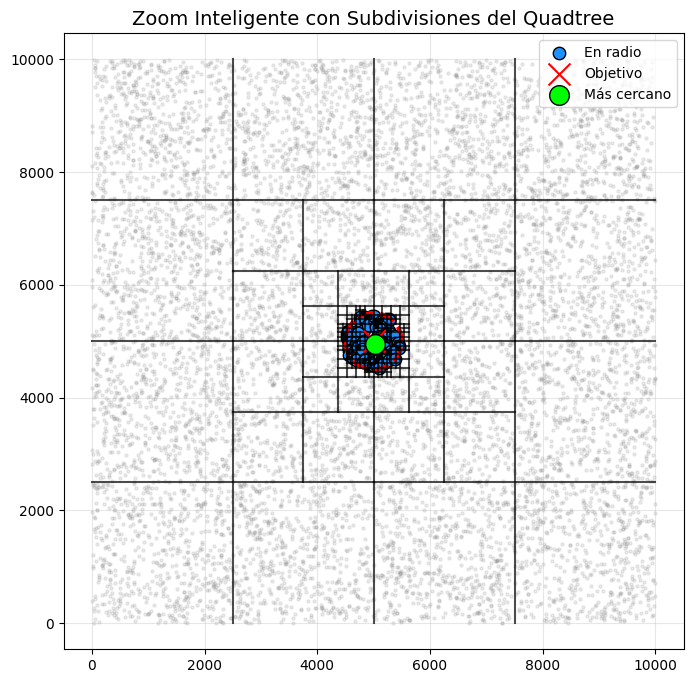

In [51]:
# -------- ZOOM INTELIGENTE (CON CONTEXTO + QUADTREE CLARO) --------
plt.figure(figsize=(8,8))
ax = plt.gca()

# 🔥 Zoom ligeramente más pequeño que el radio (para que el círculo se vea grande)
factor_zoom = 1.1
r = radio_busqueda * factor_zoom

plt.xlim(punto_objetivo[0] - r, punto_objetivo[0] + r)
plt.ylim(punto_objetivo[1] - r, punto_objetivo[1] + r)

# -------- TODOS LOS PUNTOS (fondo tenue) --------
pts_x, pts_y = zip(*puntos_entrega)
plt.scatter(pts_x, pts_y, s=5, c='gray', alpha=0.15)

# -------- PUNTOS EN EL RADIO --------
if puntos_qt:
    pr_x, pr_y = zip(*puntos_qt)
    plt.scatter(pr_x, pr_y, s=80, c='dodgerblue', edgecolors='black', label='En radio')

# -------- OBJETIVO --------
plt.scatter(*punto_objetivo, c='red', s=250, marker='x', zorder=5, label='Objetivo')

# -------- CÍRCULO --------
circulo = plt.Circle(
    punto_objetivo,
    radio_busqueda,
    color='red',
    fill=False,
    linestyle='--',
    linewidth=3
)
ax.add_patch(circulo)

# -------- VECINO MÁS CERCANO --------
if mas_cercano_qt:
    plt.scatter(*mas_cercano_qt, c='lime', s=200, edgecolors='black', zorder=6, label='Más cercano')
    plt.plot([punto_objetivo[0], mas_cercano_qt[0]],
             [punto_objetivo[1], mas_cercano_qt[1]],
             c='lime', linewidth=2)

# -------- 🔥 DIBUJAR SOLO REGIONES RELEVANTES --------
def dibujar_quadtree_filtrado(ax, nodo, xmin, xmax, ymin, ymax, objetivo, radio):
    if nodo is None:
        return

    # Solo dibujar si esta región intersecta el círculo
    if not intersecta_rectangulo(objetivo, radio, xmin, xmax, ymin, ymax):
        return

    # Dibujar líneas de subdivisión
    if nodo.izquierdaAbajo or nodo.izquierdaArriba or nodo.derechaAbajo or nodo.derechaArriba:
        cx, cy = nodo.centro

        ax.plot([cx, cx], [ymin, ymax], color='black', linewidth=1.5, alpha=0.7)
        ax.plot([xmin, xmax], [cy, cy], color='black', linewidth=1.5, alpha=0.7)

        # Recursión SOLO en zonas relevantes
        dibujar_quadtree_filtrado(ax, nodo.izquierdaAbajo, xmin, cx, ymin, cy, objetivo, radio)
        dibujar_quadtree_filtrado(ax, nodo.izquierdaArriba, xmin, cx, cy, ymax, objetivo, radio)
        dibujar_quadtree_filtrado(ax, nodo.derechaAbajo, cx, xmax, ymin, cy, objetivo, radio)
        dibujar_quadtree_filtrado(ax, nodo.derechaArriba, cx, xmax, cy, ymax, objetivo, radio)

# 🔥 Dibujar solo zonas útiles
dibujar_quadtree_filtrado(ax, arbol.raiz, 0, 10000, 0, 10000, punto_objetivo, radio_busqueda)

# -------- ESTILO --------
plt.title("Zoom Inteligente con Subdivisiones del Quadtree", fontsize=14)
plt.legend()
plt.axis('equal')
plt.grid(True, alpha=0.3)

plt.show()

# **Generacion de grafica con Zoom**
Recordatorio: Las gráficas fueron generadas por inteligencia artificial.

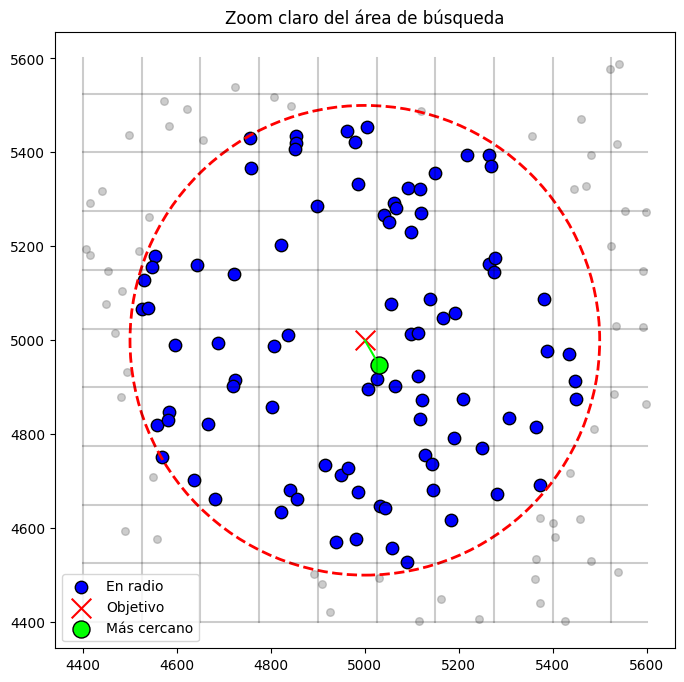

In [49]:
# -------- CONSTRUIR ÁRBOL --------
arbol = Quadtree(puntos_entrega, LIMITE_MIN, LIMITE_MAX, LIMITE_MIN, LIMITE_MAX)

# -------- CONFIGURACIÓN --------
punto_objetivo = [5000, 5000]
radio_busqueda = 500

# -------- BÚSQUEDAS --------
puntos_qt = arbol.busquedaPorRadio(punto_objetivo, radio_busqueda)
mas_cercano_qt = arbol.busquedaMasCercano(punto_objetivo)

# -------- ZOOM LIMPIO --------
plt.figure(figsize=(8,8))
ax = plt.gca()

margen = radio_busqueda * 1.2

xmin = punto_objetivo[0] - margen
xmax = punto_objetivo[0] + margen
ymin = punto_objetivo[1] - margen
ymax = punto_objetivo[1] + margen

plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)

# Filtrar puntos
pts = np.array(puntos_entrega)
filtro = (
    (pts[:,0] >= xmin) & (pts[:,0] <= xmax) &
    (pts[:,1] >= ymin) & (pts[:,1] <= ymax)
)
pts_zoom = pts[filtro]

# Puntos fondo
plt.scatter(pts_zoom[:,0], pts_zoom[:,1], s=30, c='gray', alpha=0.4)

# Puntos dentro del radio
if puntos_qt:
    pr = np.array(puntos_qt)
    plt.scatter(pr[:,0], pr[:,1], s=80, c='blue', edgecolors='black', label='En radio')

# Objetivo
plt.scatter(*punto_objetivo, c='red', s=200, marker='x', label='Objetivo')

# Círculo
circulo = plt.Circle(punto_objetivo, radio_busqueda,
                     color='red', fill=False, linestyle='--', linewidth=2)
ax.add_patch(circulo)

# Vecino
if mas_cercano_qt:
    plt.scatter(*mas_cercano_qt, c='lime', s=150, edgecolors='black', label='Más cercano')
    plt.plot([punto_objetivo[0], mas_cercano_qt[0]],
             [punto_objetivo[1], mas_cercano_qt[1]],
             c='lime')

# Cuadrícula
step = radio_busqueda / 4
x_vals = np.arange(xmin, xmax, step)
y_vals = np.arange(ymin, ymax, step)

for x in x_vals:
    ax.plot([x, x], [ymin, ymax], color='black', alpha=0.2)

for y in y_vals:
    ax.plot([xmin, xmax], [y, y], color='black', alpha=0.2)

# Estilo
plt.title("Zoom claro del área de búsqueda")
plt.legend()
plt.axis('equal')
plt.grid(False)

plt.show()

## 4. Análisis de Rendimiento: Quadtree vs. Fuerza Bruta
Para la comparación entre ambas estructuras de datos, se realiza una búsqueda 100 veces en ambos métodos y se promedia el tiempo de cada ejecución. Se realiza dicho proceso con 7 cantidades diferentes de datos, aumentandola gradualmente, para mirar cómo se comporta cuando la cantidad de datos es pequeña (100) y cómo cambia cuando va aumentando (hasta llegar a 10000).


Resultado para 100 puntos:
  Vecino Cercano:
    Quadtree: 0.000055s | Fuerza Bruta: 0.000073s
    1.32x más rápido
  Busqueda por Radio:
    Quadtree: 0.000054s | Fuerza Bruta: 0.000077s
    1.43x más rápido

Resultado para 500 puntos:
  Vecino Cercano:
    Quadtree: 0.000106s | Fuerza Bruta: 0.000361s
    3.41x más rápido
  Busqueda por Radio:
    Quadtree: 0.000111s | Fuerza Bruta: 0.000380s
    3.42x más rápido

Resultado para 1000 puntos:
  Vecino Cercano:
    Quadtree: 0.000120s | Fuerza Bruta: 0.000771s
    6.43x más rápido
  Busqueda por Radio:
    Quadtree: 0.000141s | Fuerza Bruta: 0.001015s
    7.20x más rápido

Resultado para 2500 puntos:
  Vecino Cercano:
    Quadtree: 0.000269s | Fuerza Bruta: 0.004066s
    15.09x más rápido
  Busqueda por Radio:
    Quadtree: 0.000397s | Fuerza Bruta: 0.003845s
    9.70x más rápido

Resultado para 5000 puntos:
  Vecino Cercano:
    Quadtree: 0.000286s | Fuerza Bruta: 0.007713s
    26.94x más rápido
  Busqueda por Radio:
    Quadtree: 0.

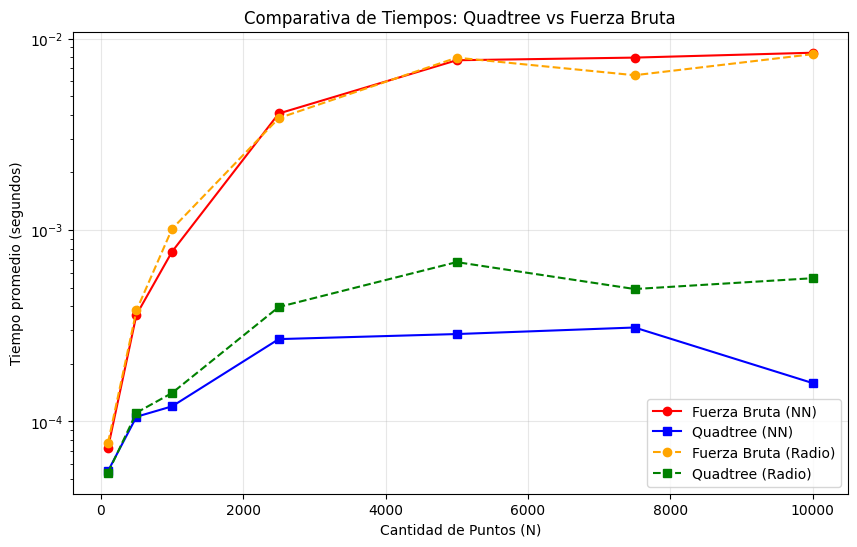

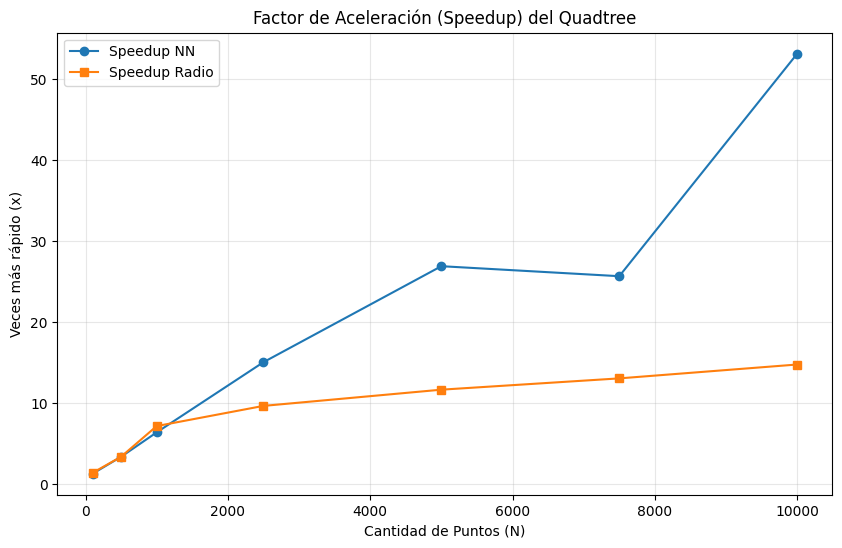

In [57]:
import time

"""FUNCION buscar_mas_cercano_fuerza_bruta(): Ingresamos como parametro todos los puntos, y el punto al cual queremos conocerle su más cercano.
Lo que hace el algoritmo es calcular la distancia euclidiana entre el punto objetivo y cada punto dentro del array. Debe pasar por todos los elementos del array obligatoriamente (costoso) """

def buscar_mas_cercano_fuerza_bruta(puntos, objetivo):
    mejor_punto = None
    mejor_distancia = float('inf')
    for p in puntos:
        dist = calcularDistancia(p, objetivo)
        if dist < mejor_distancia:
            mejor_distancia = dist
            mejor_punto = p
    return mejor_punto

"""FUNCION buscar_por_radio_fuerza_bruta(): Recibe como parametros la lista de puntos, el objetivo sobre el cual vamos a trazar el radio, y el radio de busqueda. Su funcionamiento es analogo al de buscar_mas_cercano,
evalua distancia entre el objetivo y cada punto dentro de la lista: si es menor que el radio que pasamos como parametro, lo ingresamos al array de puntos cercanos. De nuevo, como no se delimita de ninguna manera
a nivel espacial, es necesario recorrer todos los elementos del array (costoso).
"""

def buscar_por_radio_fuerza_bruta(puntos, objetivo, radio):
    cercanos = []
    for p in puntos:
        if calcularDistancia(p, objetivo) <= radio:
            cercanos.append(p)
    return cercanos


# Configuracion del experimento para el analisis
tamanos = [100, 500, 1000, 2500, 5000, 7500, 10000] #Arreglo de tamaños para ensayar ambas estructuras de datos en diferentes condiciones: con 100 puntos, 500 puntos, 1000 puntos, ..., 10000 puntos.

tiempos_quadtree = [] #arreglos para almacenar el tiempo asociado a cada cantidad de puntos. Importante para graficar.
tiempos_fuerza_bruta = []

tiempos_quadtree_radio = []
tiempos_fb_radio = []

# SPEEDUPS
speedups_nn = []
speedups_radio = []


# -------- BENCHMARK --------

for n in tamanos:  #Para cada numero de datos, hacemos un slice de la lista anteriormente generada.
    puntos_test = puntos_entrega[:n]  # Usamos un subconjunto de los puntos de entrega generados anteriormente

    arbol_test = Quadtree(puntos_test, LIMITE_MIN, LIMITE_MAX, LIMITE_MIN, LIMITE_MAX)  #Creamos el arbol con el numero de datos asociado

    objetivo_test = [5000, 5000]
    radio_test = 500

    # -------- VECINO MAS CERCANO --------

     # Medimos el tiempo de busqueda con el arbol
    # Promediamos sobre 100 iteraciones para mayor precisión
    inicio = time.time()
    for _ in range(100):
        arbol_test.busquedaMasCercano(objetivo_test)
    t_qt = (time.time() - inicio) / 100
    tiempos_quadtree.append(t_qt)


    inicio = time.time()
    for _ in range(100):
        buscar_mas_cercano_fuerza_bruta(puntos_test, objetivo_test)
    t_fb = (time.time() - inicio) / 100
    tiempos_fuerza_bruta.append(t_fb)

    # speedup NN
    speedup_nn = t_fb / t_qt if t_qt > 0 else float('inf')
    speedups_nn.append(speedup_nn)

    # -------- BUSQUEDA POR RADIO --------
    #MEDICION PUNTOS ENCONTRADOS POR RADIO
    #Medimos el tiempo de busqueda por radio en cada caso, y se promedia el valor de 100 ejecuciones.
    inicio = time.time()
    for _ in range(100):
        arbol_test.busquedaPorRadio(objetivo_test, radio_test)
    t_qt_r = (time.time() - inicio) / 100
    tiempos_quadtree_radio.append(t_qt_r)

    inicio = time.time()
    for _ in range(100):
        buscar_por_radio_fuerza_bruta(puntos_test, objetivo_test, radio_test)
    t_fb_r = (time.time() - inicio) / 100
    tiempos_fb_radio.append(t_fb_r)

    # speedup RADIO
    speedup_radio = t_fb_r / t_qt_r if t_qt_r > 0 else float('inf')
    speedups_radio.append(speedup_radio)

    # -------- PRINT --------

    print(f"\nResultado para {n} puntos:")
    print(f"  Vecino Cercano:")
    print(f"    Quadtree: {t_qt:.6f}s | Fuerza Bruta: {t_fb:.6f}s")
    print(f"    {speedup_nn:.2f}x más rápido")

    print(f"  Busqueda por Radio:")
    print(f"    Quadtree: {t_qt_r:.6f}s | Fuerza Bruta: {t_fb_r:.6f}s")
    print(f"    {speedup_radio:.2f}x más rápido")


# -------- RESUMEN --------

print("\n\n======== RESUMEN ========")

print("\nSpeedup Vecino más cercano:")
for n, s in zip(tamanos, speedups_nn):
    print(f"  {n} puntos → {s:.2f}x")

print("\nSpeedup Busqueda por radio:")
for n, s in zip(tamanos, speedups_radio):
    print(f"  {n} puntos → {s:.2f}x")


#GRAFICAR RESULTADOS (HECHO POR CHATGPT)-

plt.figure(figsize=(10, 6))

plt.plot(tamanos, tiempos_fuerza_bruta, label='Fuerza Bruta (NN)', marker='o', color='red')
plt.plot(tamanos, tiempos_quadtree, label='Quadtree (NN)', marker='s', color='blue')

plt.plot(tamanos, tiempos_fb_radio, label='Fuerza Bruta (Radio)', marker='o', color='orange', linestyle='--')
plt.plot(tamanos, tiempos_quadtree_radio, label='Quadtree (Radio)', marker='s', color='green', linestyle='--')

plt.title("Comparativa de Tiempos: Quadtree vs Fuerza Bruta")
plt.xlabel("Cantidad de Puntos (N)")
plt.ylabel("Tiempo promedio (segundos)")
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()


#GRAFICAR RESULTADOS (HECHO POR CHATGPT)

plt.figure(figsize=(10, 6))

plt.plot(tamanos, speedups_nn, label='Speedup NN', marker='o')
plt.plot(tamanos, speedups_radio, label='Speedup Radio', marker='s')

plt.title("Factor de Aceleración (Speedup) del Quadtree")
plt.xlabel("Cantidad de Puntos (N)")
plt.ylabel("Veces más rápido (x)")
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

## 5. ANALISIS Y CONCLUSIONES
Tras las pruebas realizadas podemos determinar que:

- **El Quadtree demuestra su eficiencia desde escalas pequeñas**:


Podemos observar que el Quadtree se muestra superior incluso en escalas de datos pequeñas. Mientras que tiempo de búsqueda tanto por radio como por el más cercano se dispara en el caso de fuerza bruta, al pasar de **100 a 500**, el ArbolKD tiene un tiempo supremamente bajo y estable; con aumentar de 100 a 500, el tiempo de búsqueda es más de 3 veces más rápido, y con el aumento de puntos, su velocidad sigue siendo considerablemente mejor en comparación con fuerza bruta (en 10000 puntos, 57 veces más rápido en el ejemplo).

- **Escalabilidad**: La diferencia en rendimiento se marca muchísimo con el crecimiento del numero de puntos. El costo de búsqueda dentro de fuerza bruta es lineal: es necesario hacer una comparación con cada punto dentro del arreglo. Por otro lado, el Quadtree, a través de esos descartes inteligentes por regiones y esa ubicación espacial establecida, hace que la búsqueda no sea completamente a ciegas; la hace más ordenada, sabiendo a dónde ir, y más importante, a dónde definitivamente no ir (cuando es totalmente imposible llegar ahí)

- **Rendimiento de la división espacial:** En cantidades grandes de datos, el arbol puede descartar regiones inmensas del espacio con pocas comparaciones. Por eso, aunque aumentemos la escala del número de puntos, el tiempo que se toma encontrar un punto dentro de ese espacio no crece de la misma manera (El tiempo de búsqueda no crece proporcionalmente a la cantidad de datos).